In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, recall_score

In [ ]:
df = pd.read_csv('/content/Loan_default.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

# Data Understanding

This dataset has been taken from Coursera's Loan Default Prediction Challenge and will provide you the opportunity to tackle one of the most industry-relevant machine learning problems with a unique dataset that will put your modeling skills to the test. The dataset contains 255,347 rows and 18 columns in total.

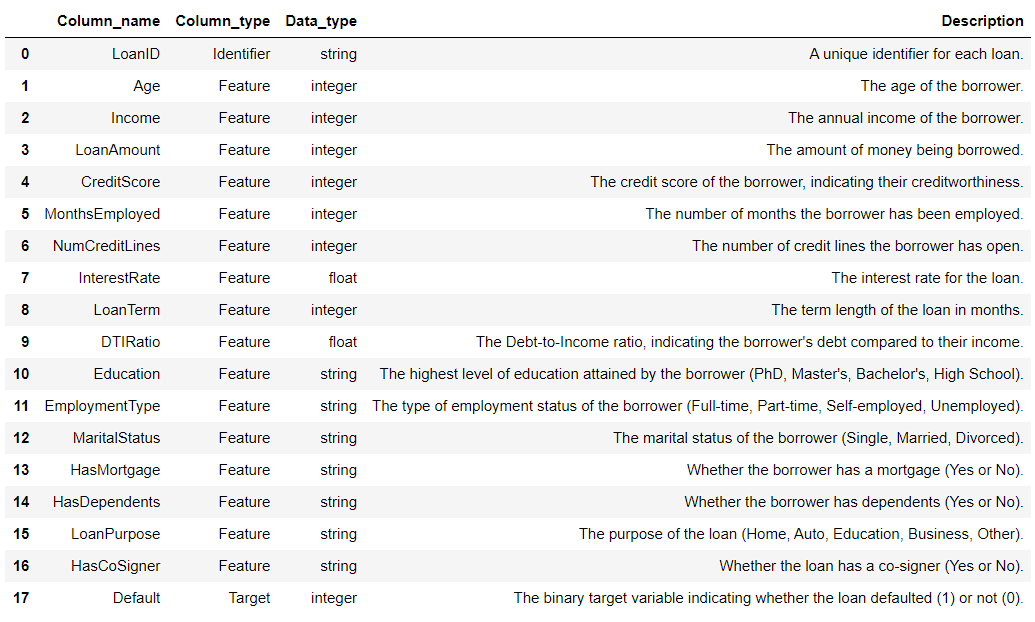

# Goals



Berdasarkan data tersebut, beberapa tujuan bisnis potensial yang dapat dijawab melalui pemodelan dan analisis adalah:

**Business Problem:**

Banyak institusi keuangan mengalami kerugian karena tingkat gagal bayar (loan default) yang tinggi. Perlu adanya model prediksi untuk mengidentifikasi nasabah yang berpotensi gagal bayar sebelum pinjaman diberikan.

**Analytical Goal:**

Mengembangkan model klasifikasi yang dapat memprediksi risiko gagal bayar nasabah berdasarkan informasi profil dan pinjamannya.

**Business Goal:**

Mengurangi kerugian finansial dan meningkatkan efisiensi penyaluran kredit dengan menolak pengajuan berisiko tinggi, atau menyesuaikan syarat pinjaman bagi calon peminjam yang memiliki kemungkinan default tinggi.

# Data Cleaning

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(['LoanID'], axis=1, inplace=True)

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Data Manipulation

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
binary_cols = ["HasMortgage", "HasDependents", "HasCoSigner"]

for col in binary_cols:
    df[col] = (df[col]
               .str.lower()
               .str.strip()
               .map({"yes": 1, "no": 0}))

In [ ]:
multi_cat_cols = ["Education", "EmploymentType",
                  "MaritalStatus", "LoanPurpose"]

df = pd.get_dummies(df,
                    columns=multi_cat_cols,
                    drop_first=True)

In [ ]:
num_cols = ["Age", "Income", "LoanAmount", "CreditScore",
            "MonthsEmployed", "NumCreditLines",
            "InterestRate", "LoanTerm", "DTIRatio"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# EDA

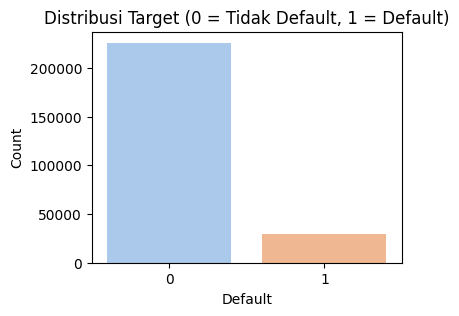

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(x=y, palette="pastel")
plt.title("Distribusi Target (0 = Tidak Default, 1 = Default)")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

Kelas Default (1) hanya mencakup sekitar 11.6% dari total data, sedangkan sisanya (~88.4%) adalah kelas non-default (0). Sehingga Data imbalance.

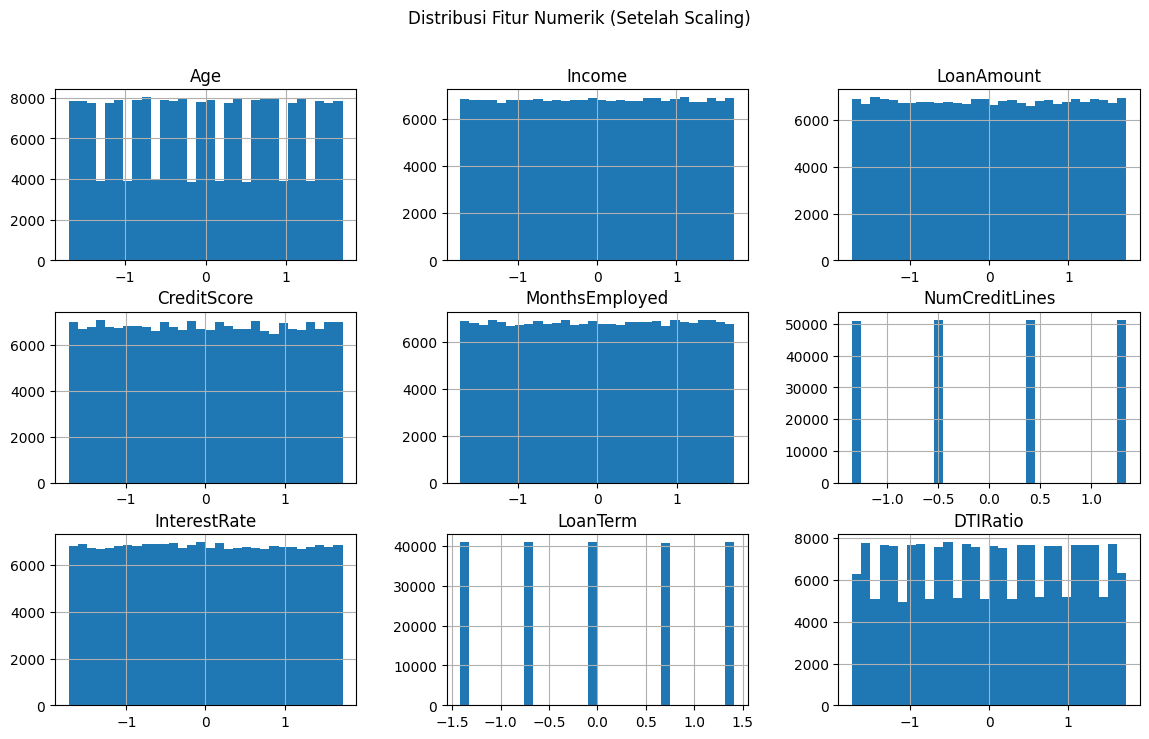

In [ ]:
X_train[num_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Distribusi Fitur Numerik (Setelah Scaling)")
plt.show()

a. Income dan LoanAmount:
- Distribusi simetris dan cukup tersebar luas.
- Tidak ada outlier ekstrem karena sudah di-scale.
- Menunjukkan bahwa peminjam berasal dari latar belakang finansial yang beragam.

b. CreditScore:
Tersebar cukup baik, tidak terlalu skewed.

c. DTIRatio (Debt-to-Income Ratio):
Berdistribusi relatif normal (mean sekitar 0.5).

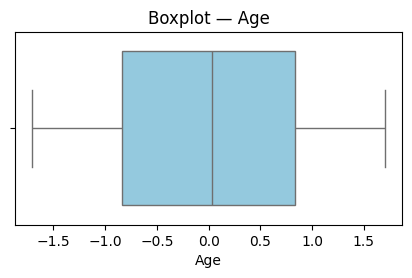

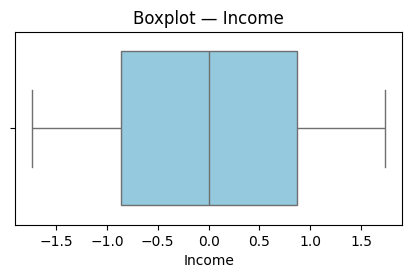

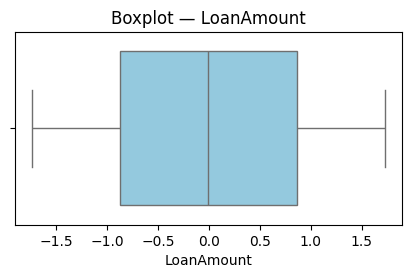

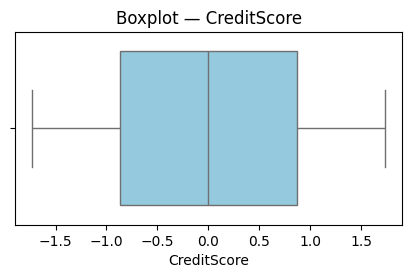

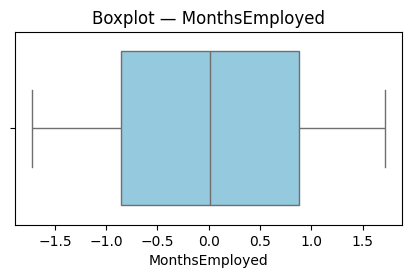

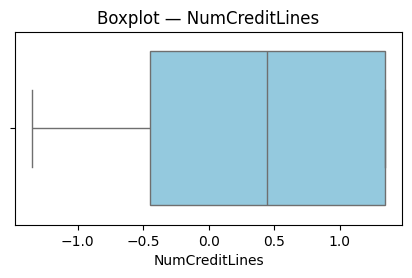

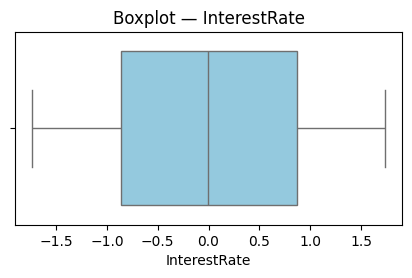

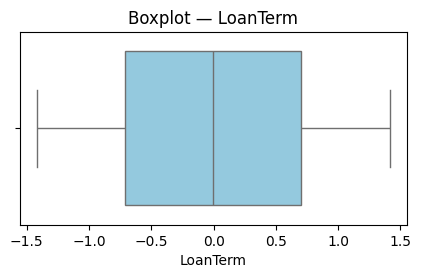

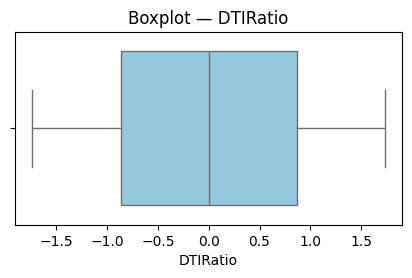

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5, 2.5))
    sns.boxplot(x=X_train[col], color="skyblue")
    plt.title(f"Boxplot — {col}")
    plt.show()

- Sebagian fitur seperti Income dan LoanAmount memiliki outlier, meskipun sudah di-scale.

- Namun karena datanya besar (>250 ribu), keberadaan outlier tidak terlalu bermasalah selama distribusinya wajar.

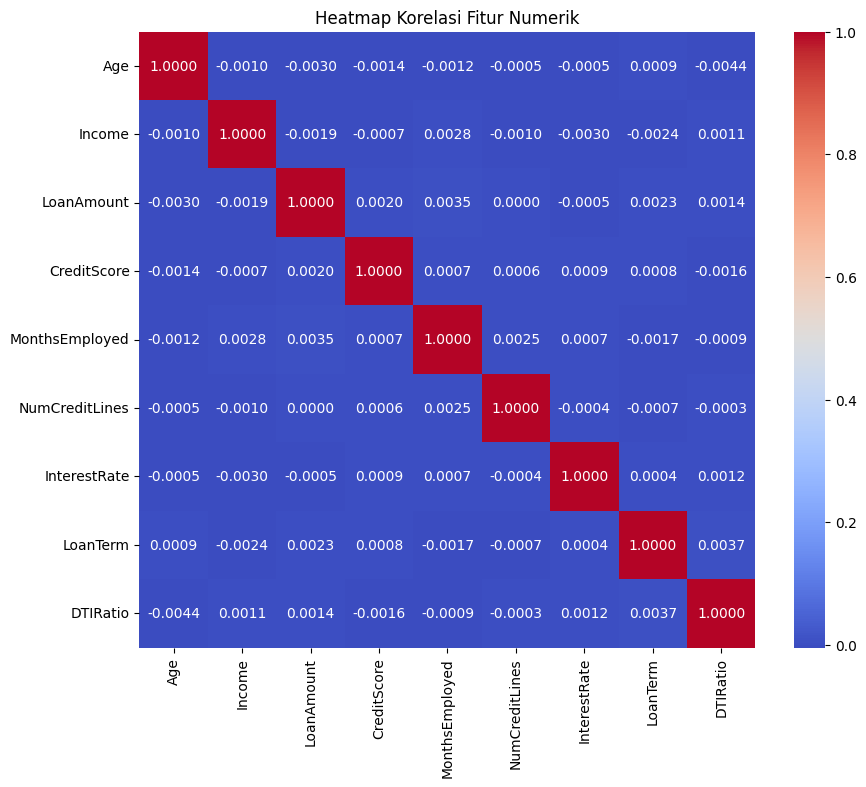

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[num_cols].corr(),
            annot=True, fmt=".4f", cmap="coolwarm", square=True)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

Korelasi yang signifikan:

- Income dan LoanAmount: korelasi positif moderat → peminjam dengan penghasilan lebih tinggi cenderung meminjam lebih besar.

- LoanTerm dan LoanAmount: positif → semakin panjang tenor, semakin besar nilai pinjaman.

- Tidak ada korelasi kuat antar fitur numerik (> 0.9) → tidak perlu reduksi fitur saat ini.

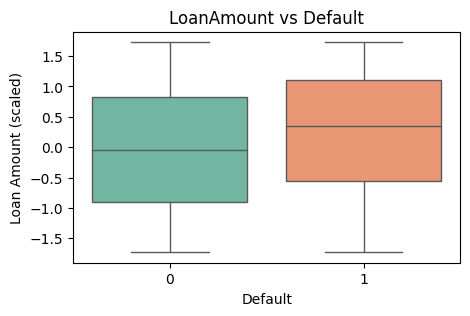

In [ ]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=y_train, y=X_train["LoanAmount"], palette="Set2")
plt.title("LoanAmount vs Default")
plt.xlabel("Default")
plt.ylabel("Loan Amount (scaled)")
plt.show()

Boxplot menunjukkan:

Peminjam yang gagal bayar (Default=1) cenderung memiliki pinjaman lebih kecil dibanding yang tidak default.

Interpretasi:

Pinjaman kecil tidak selalu aman. Bisa jadi karena peminjam dengan pinjaman kecil berasal dari kelompok risiko tinggi (misal: penghasilan rendah, skor kredit rendah).

# SMOTE ( Data Imbalance )

In [ ]:
!pip install imbalanced-learn
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
X = df.drop(columns=["Default"])
y = df["Default"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:")
print(y_train.value_counts())
print("\nSetelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Sebelum SMOTE:
Default
0    180555
1     23722
Name: count, dtype: int64

Setelah SMOTE:
Default
0    180555
1    180555
Name: count, dtype: int64


# Random Forest

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== ROC AUC Score ===")
print(roc_auc_score(y_test, y_proba))


=== Confusion Matrix ===
[[41535  3604]
 [ 4236  1695]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     45139
           1       0.32      0.29      0.30      5931

    accuracy                           0.85     51070
   macro avg       0.61      0.60      0.61     51070
weighted avg       0.84      0.85      0.84     51070


=== ROC AUC Score ===
0.7298789457584675


**Interpretasi Hasil Model**

Akurasi: 85%
-   Secara umum, model memprediksi dengan akurasi tinggi.
- Namun perlu hati-hati: karena data tidak seimbang, akurasi tinggi bisa menyesatkan jika model terlalu fokus pada kelas mayoritas (tidak default).

Recall (Default = 1): 29%

-  Model hanya bisa mendeteksi 29% dari total nasabah yang benar-benar gagal bayar.
-  Ini berarti 71% nasabah default tidak terdeteksi (false negative tinggi).
-  Untuk bisnis, ini berisiko karena pinjaman bisa dikucurkan ke nasabah yang gagal bayar tanpa terdeteksi.

Precision (Default = 1): 32%

-  Dari semua nasabah yang diprediksi akan default, hanya 32% yang benar-benar gagal bayar.
-  Masih banyak “alarm palsu” → bisa menyebabkan penolakan yang tidak perlu.

F1 Score (Default = 1): 0.30

-  Menunjukkan bahwa keseimbangan antara recall dan precision masih rendah untuk kelas default.
-  Ini menandakan model belum optimal untuk mendeteksi nasabah berisiko tinggi.

ROC AUC = 0.73
- Termasuk baik (≥ 0.7), artinya model cukup mampu membedakan antara nasabah yang akan default dan tidak.
- Semakin mendekati 1, semakin baik kemampuan diskriminatif model.

**Implikasi Bisnis**

- Model ini cocok untuk digunakan sebagai sistem peringatan awal (early warning system).

- Disarankan untuk mengombinasikan hasil model dengan evaluasi manual atau sistem scoring tambahan.

- Bisa digunakan untuk menyesuaikan bunga, tenor, atau jaminan bagi nasabah yang dinilai berisiko.

- Perlu peningkatan model (misalnya melalui threshold tuning, model lain, atau feature selection) jika ingin meningkatkan recall.

tidak maksimal

# XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [ ]:
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== Confusion Matrix (XGBoost) ===")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n=== Classification Report (XGBoost) ===")
print(classification_report(y_test, y_pred_xgb))

print("\n=== ROC AUC Score (XGBoost) ===")
print(roc_auc_score(y_test, y_proba_xgb))


=== Confusion Matrix (XGBoost) ===
[[32748 12391]
 [ 2212  3719]]

=== Classification Report (XGBoost) ===
              precision    recall  f1-score   support

           0       0.94      0.73      0.82     45139
           1       0.23      0.63      0.34      5931

    accuracy                           0.71     51070
   macro avg       0.58      0.68      0.58     51070
weighted avg       0.85      0.71      0.76     51070


=== ROC AUC Score (XGBoost) ===
0.7414673509906038


**Interpretasi Perbandingan**
1. XGBoost lebih baik untuk deteksi nasabah default
 - Recall meningkat dari 29% → 63%
 - Artinya XGBoost mampu menangkap lebih dari dua kali lipat jumlah nasabah berisiko dibanding Random Forest.
 - Ini sangat penting dalam manajemen risiko kredit.

2. Trade-off: Precision turun
 - Precision XGBoost lebih rendah (23%) dibanding Random Forest (32%).
 - Artinya, XGBoost lebih banyak false positive: memprediksi orang akan default padahal tidak.

3. Akurasi lebih rendah? Itu wajar!
 - Akurasi XGBoost turun karena model lebih berani menandai nasabah sebagai "berisiko".
 - Dalam konteks data imbalance, recall untuk kelas minoritas lebih penting daripada akurasi keseluruhan.

4. ROC AUC lebih baik di XGBoost
 - AUC meningkat dari 0.729 → 0.741 → menunjukkan XGBoost lebih baik dalam membedakan kelas default vs tidak.

# Feature Importance

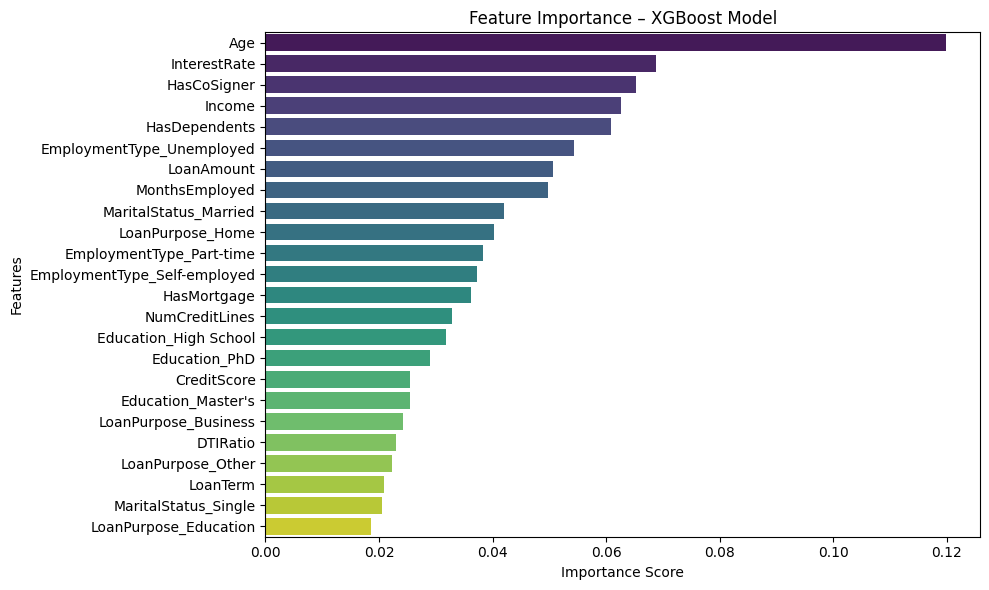

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

feature_names = X_train.columns
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance – XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()